# Equations of State

Topics covered in this section include

- [Equations of State](#2.1)

- [Ideal Gas Law](#2.2)

- [Thermal Equations of State](#2.3)

- [Heat Capacities and the Ideal Gas Heat Capacity](#2.4)

For supplemental reading please visit the following links:

- links to OER relevant to this topic.

<a id="2.1"></a>
## Definition of Equation of State (EoS)

### Gibbs' Phase Rule 

Gibbs defined a phase rule the sets the number of degrees of freedom of a system as:

$$F=2-P+C$$

where 

- $F$ is the number of degrees of freedom

- $P$ is the number of phases

- $C$ is the number of components. 

This rule sets how many state variables can be modified at a time without the others being effect. For a 1-phase, 1-component system there are $F=2$ so we can independently change any pair of state variable without affecting the others.


### Generalized Equations of State

An equation of state is a relation that links one state variable to two others for a system in equilibrium while obeying Gibbs' phase rule. There are two types of equations of state:

- Volumetric Equations of State: Ex. $P=f(V,T,N,x_i)$

- Thermal Equations of State: Ex. $U=f(V,T,N,x_i)$

In this way, equations of state involve the relationship between state variables. This will be a recurring theme throughout thermodynamics, seeking to develop expressions for one thermal variable (ex. $U$) in terms of other variables such as $P$, $V$, or $T$. 

We will see in Chapter 4 that volumetric equations of state can be quite complex. We will also see that thermal equations of state would be extremely useful for problem solving, but unfortunately they are generally not available to researchers, experimentalists, and engineers. Instead, we rely heavily on thermodynamics to link thermal variables to volumetric variables and describe state changes using volumetric equations of state. This is one of the core ideas that you will learn in this course.


###  Discovery of Gas Laws - The Ideal Gas Thermometer:
<a id="2.2"></a>

Volumetric Equations of state have the form $P=f(V,T,N, x_i)$ and are the most accessible and common forms of the equations of state. This is because the volumetric variables are easily measured and manipulated in laboratory settings such that correlations between them can be developed using robust data sets.

In the early days of thermodynamics, the gas laws had not yet been discovered. You can read about early gas laws [here](https://en.wikipedia.org/wiki/Gas_laws). The means of discovery was experimental apparatus like that depicted in the figure below where a low pressure gas was confined in a cylinder of known diameter. The cylinder was then heated/cooled causing the gas to expand/compress, resulting in the cylinder plunger moving a distance, $\Delta L$. At the same time, the force required, $\Delta F$, to hold the plunger in place could be measured using a scale and the temperature within the system monitored by the height of a liquid, $\Delta h$, in an evacuated column (a simple thermometer).


<img src=images/0th-Law-of-Thermodynamics.png alt="drawing" style="width:500px;"/>

For a well-design apparatus, we might find the following relationships,

- When $\Delta L=0$ (this is a so-called **isochoric/isometric pathway**), heat was added/removed to the system resulting in a change in the force acting on the piston and the liquid height. 

- When $\Delta F=0$ (this is a so-called isobaric pathway), heat was added/removed to the system causing the cylinder's volume and the liquid height to change. 

Experimentalists observing this behavior would have noted that for any pair of measured properties any value of the other property could have been measured. By controlling only one degree of freedom, a single degree of freedom remained allowing pairs of properties to adopt any value.

However, if instead control two of these properties simultaneously, Ex:

- When $\Delta L=0$ and  $\Delta F=0$, adding/removing heat to the system caused the liquid height to change linearly with the amount of heat added or removed. 

From these measurements, data plotted as $\Delta F \Delta L$ vs $\Delta h$ would have yielded a straight line whose slope and intercept changed with the accuracy and units of the measurement device. However, when the $\Delta h$ was calibrated to the melting point and boiling point of water and the intercept of that line was identically equal to $0$ if the temperature units were in $K$. 

Defining the $P_g=\dfrac{\Delta F}{A}$ and the molar volume $\underline{V}=\dfrac{\Delta L\times A}{N}$, it would have been possible to define the gas constant $R$ and the ideal gas law.

## Ideal Gas Law:
<a id="2.2"></a>

The ideal gas law describes the relationship between volumetric variables $P$, $\underline{V}$, $T$ and the gas constant $R$. The ideal gas law is used for single phase gases that are significantly expanded (or $P\rightarrow 0$, $\underline{V}\rightarrow \infty$). For any singe component, ideal gas, the number of degrees of freedom is $2$. The ideal gas law is written as:

$\quad \quad P\underline{V}=RT$

The number of DOF are reflected directly in the form of the equation. For example, if I specify the $P$ and $T$, then the molar volume, $\underline{V}$ is fixed. All equations of state that one can define will obey Gibbs' Phase Rule.


To visualize the ideal gas law, let's plot a few **isotherms** (or lines of constant temperature) of the ideal gas law. To do so, we will first import **numpy** for array manipulation and **matplotlib.pyplot** for plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Then we will define the gas constant as a global variable, $R=8.314 \big[J/(mol\cdot K) \big]$

In [2]:
R = 8.314 #J/(mol*K)

To plot a line it is convenient to create an array. As gas properties vary widely over a large range of molar volumes, it is useful to define the spacing of that array on the logarithmic scale. Numpy has a convenient function for this **np.logspace()**

In [33]:
volumes = np.logspace(-4,-1, 51)

To plot the ideal gas law, you may find it convenient to define a function. Functions in python can be instantiated by the **def** decorator. Because the ideal gas law requires two inputs (DOF), we will pass two parameters to the function:

1. The temperature ($K$) as a scalar
2. The molar volume ($m^3/mol$) as a vector

The output will the Pressure in $Pa$ as a vector of the same shape as the volume.

In [18]:
def idealgaslaw(T,V):
    '''
    T is the temperature in K (scalar)
    V is the molar volume (array of shape N) in m^3/mol

    returns Pressure in Pa (array of shape N)
    '''
    return R*T/V

Now we can conveniently create a plot of multiple isotherms using a **for** loop. We are going to plot the molar volumes on the x-axis and the resulting Pressures on the y-axis. The plot will include:

1. figure labels
2. Legend

to format the legend, we use an "f-string" which can help format floating point and integers into strings. 

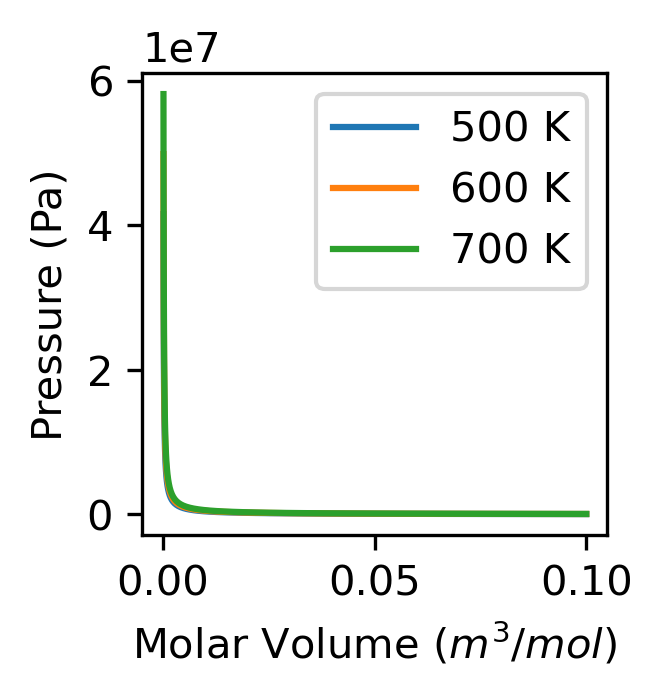

In [34]:
plt.figure(dpi=300, figsize=(2,2))
for T in [500, 600, 700]:
    plt.plot(volumes, idealgaslaw(T, volumes), label = f'{T} K')

plt.ylabel('Pressure (Pa)')
plt.xlabel('Molar Volume ($m^3/mol$)')
plt.legend()

Because the ideal gas law written explicitly for Pressure has the form $P(\underline{V}, T)=\dfrac{RT}{\underline{V}}$. An isotherm of the ideal gas law is a power-law function where $P~1/\underline{V}$ the result is that there is a strong variation of the Pressure with the molar volume over a wide-range of molar volumes that real gases are used.

Therefore, we need a better way to visualize real gas data and the ideal gas law. The best way to do this is to create a log-log plot of the ideal gas law. In the log-log plot, the axes are transformed to space the distance between tick marks logarthmically between decades of y-axis value. The easiest way to think about the log-log plot is that the spacing of each point on the x- and y- axes is the logarithm (base 10) of the true value and the axes are simply labeled with the true value instead of its logarithm. 


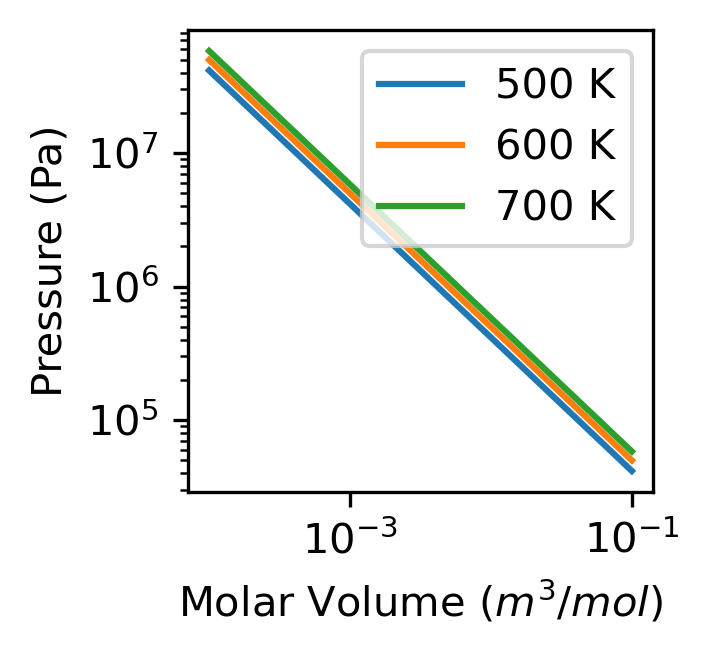

In [35]:
plt.figure(dpi=300, figsize=(2,2))
for T in [500, 600, 700]:
    plt.plot(volumes, idealgaslaw(T, volumes), label = f'{T} K')

plt.ylabel('Pressure (Pa)')
plt.xlabel('Molar Volume ($m^3/mol$)')
plt.yscale('log')
plt.xscale('log')
plt.legend()

## Steam Tables: Real Gas Properties

Of course the ideal gas law is severely limited to prediction of real gas properties in the infinitely expanded limit ($P\rightarrow0$ and $\underline{V}\rightarrow \infty)$. Deviation of *real gas properties* is best visualized on the $P-\underline{V}$ diagram. 

To visualize this deviation, it is convenient to do some unit conversion first. The steam tables in the back of Sandler use the following units:

1. Pressure is expressed in $MPa = 10^6 Pa$
2. Molar Volume is expressed in intensive units of $m^3/kg$, so to convert we need the molecular weight of steam (water) which is $0.018$ $kg/mol$
3. Temperature is also in $(^o C)$ so it would be convenient to define our temperatures in units of (*C) for direct comparison with the steam tables.

To simplify things further, we will focus on only a single isotherm.

Let's do that unit conversion before plotting:

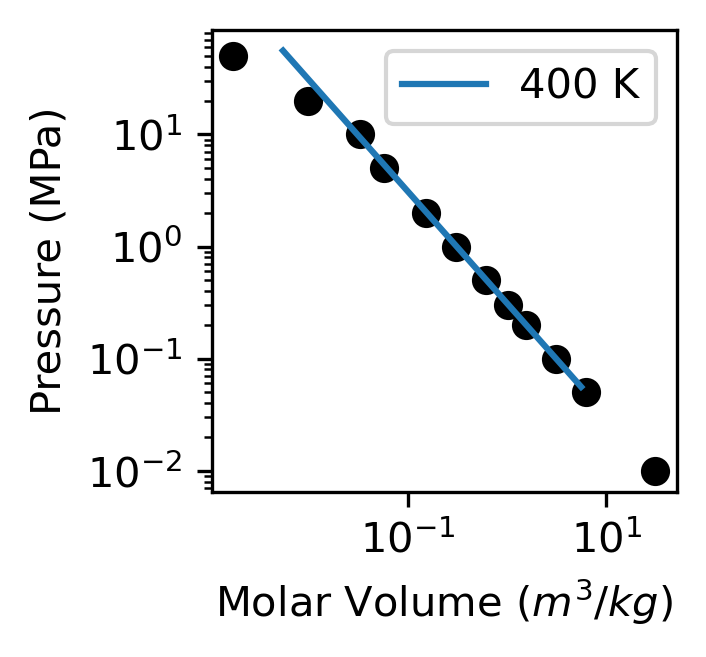

In [36]:
plt.figure(dpi=300, figsize=(2,2))

MW_steam = 0.018 #kg/mol
Pa_MPa = 10**-6 # Multiply number to get to MPa
temperatures = [500] #C

steam_pressures = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
steam_volumes_500C = [35.679, 7.134, 3.565, 1.7814, 1.1867, 0.7109, 0.3541, 0.176, 0.06857, 0.03279, 0.0148, 0.003892]
steam_volumes_400C = [31.063, 6.2096, 3.103, 1.5493, 1.0315, 0.6173, 0.3066, 0.151, 0.0578, 0.03279, 0.009942, 0.001731] 
#steam_volumes_300C = [26.445, 5.284, 2.639, 1.3162, 0.8753, 0.5226, 0.2579, 0.1255, 0.04532, 0.018026]

plt.plot(steam_volumes_400C, steam_pressures, 'ok')

for T in [400]:
    plt.plot(volumes/MW_steam, idealgaslaw(T + 273.15, volumes)*Pa_MPa, label = f'{T} K')

#plt.plot(steam_volumes_500C, steam_pressures, '-k')
#plt.plot(steam_volumes_400C, steam_pressures, '-k')


plt.ylabel('Pressure (MPa)')
plt.xlabel('Molar Volume ($m^3/kg$)')
plt.yscale('log')
plt.xscale('log')
plt.legend()

<a id="2.4"></a>
## Heat Capacities

A final critical observation derived from experiments described above was that: 

- when $\Delta P$ was constant, heat was added to an ideal gas would cause a linear increase in temperature such that

    - $\Delta Q=C_{P}^{IG} \Delta T$.
    

- when $\Delta \underline{V}=0$ , heat was added to an ideal gas would case a linear increase in temperature such that

    - $\Delta Q=C_{V}^{IG} \Delta T$.
    
    
It was further observed that the temperature rise was less for the constant $P$ case than for the constant $V$ case. For an ideal gas, this implied that $C_P>C_V$.

The constants in the equations above are defined as the **heat capacities** and have the definition:

$$ C_{P}=\bigg(\dfrac{\partial \underline{H}}{\partial T}\bigg)_{P}$$

$$ C_{V}=\bigg(\dfrac{\partial \underline{U}}{\partial T}\bigg)_{\underline{V}}$$

In Chapter 2, we will define this more clearly, but for now it is sufficient to say that the enthalpy, $\underline{H}$, and internal energy, $\underline{U}$, are thermal variables that track the amount of heat containg within a substance.

### Temperature dependence of the Ideal Gas Heat Capacities

As the equation above implies, the heat capacities of ideal gases are either constants or only functions of temperature. Empirical equations exist that allow for the estimation of an ideal gas at any temperature. One such equation is given as:

$C_{P}^{IG}=a+b T+c T^2+d T^3$

and by definition

$C_{V}^{IG}=C_P^{IG}-R$

Heat capacities have units of $J/(mol\cdot K$). These values are tabulated in https://chemicals.readthedocs.io/